# FatigueGuard Mining — ML clásico con landmarks

Se entrenan únicamente Random Forest y XGBoost sobre las ventanas calibradas del notebook 08.
La selección de modelo y threshold usa exclusivamente Validation. Test permanece cerrado hasta
completar ambas decisiones y se evalúa una sola vez.

Este notebook utiliza el dataset procesado generado en el notebook anterior. El archivo final se incluye en `data/processed/` para reproducir directamente el entrenamiento y la evaluación de los modelos sin volver a procesar los videos originales.

## 1. Configuración y carga del dataset

In [1]:
import time
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import xgboost as xgb
from IPython.display import Markdown, display
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix, f1_score, precision_score,
    recall_score, roc_auc_score,
)

RANDOM_STATE = 42
start = Path.cwd().resolve()
PROJECT_ROOT = start if (start / "data").exists() else start.parent
DATA_PATH = PROJECT_ROOT / "data/processed/uta_rldd_landmark_windows.csv"
METRICS_DIR = PROJECT_ROOT / "outputs/metrics"
FIGURES_DIR = PROJECT_ROOT / "outputs/figures"
MODELS_DIR = PROJECT_ROOT / "models"
for folder in [METRICS_DIR, FIGURES_DIR, MODELS_DIR]:
    folder.mkdir(parents=True, exist_ok=True)
assert DATA_PATH.exists()

experiment_start = time.perf_counter()
data = pd.read_csv(DATA_PATH, dtype={"subject_id": str})
data["subject_id"] = data.subject_id.str.zfill(2)
print(f"Dataset: {data.shape}")
print(f"XGBoost: {xgb.__version__}")

Dataset: (6633, 31)
XGBoost: 3.4.0


## 2. Features, target y split existente

Se excluyen identificadores, etiqueta, split y límites temporales. No se crea ninguna nueva
partición ni se aplican SMOTE o selección de variables.

In [2]:
excluded_columns = {
    "subject_id", "video_id", "state_code", "label", "split",
    "window_start", "window_end", "filepath", "filename",
}
feature_columns = [
    column for column in data.columns
    if column not in excluded_columns and pd.api.types.is_numeric_dtype(data[column])
]
assert len(feature_columns) == 24
assert data[feature_columns].notna().all().all()

tables = {
    split: data[data.split == split].reset_index(drop=True)
    for split in ["Train", "Validation", "Test"]
}
X_train, y_train = tables["Train"][feature_columns], tables["Train"].label
X_validation, y_validation = tables["Validation"][feature_columns], tables["Validation"].label

train_subjects = set(tables["Train"].subject_id)
validation_subjects = set(tables["Validation"].subject_id)
test_subjects = set(tables["Test"].subject_id)
assert train_subjects.isdisjoint(validation_subjects)
assert train_subjects.isdisjoint(test_subjects)
assert validation_subjects.isdisjoint(test_subjects)
assert [len(train_subjects), len(validation_subjects), len(test_subjects)] == [41, 9, 9]

print(f"Features: {len(feature_columns)}")
print("Sujetos Train / Validation / Test:", 41, 9, 9)
display(data.groupby(["split", "label"]).size().unstack(fill_value=0))

Features: 24
Sujetos Train / Validation / Test: 41 9 9


label,0,1
split,,
Test,555,486
Train,2229,2382
Validation,465,516


## 3. Funciones de evaluación

In [3]:
def metrics_at_threshold(y_true, probabilities, threshold=0.5):
    predictions = (np.asarray(probabilities) >= threshold).astype(int)
    matrix = confusion_matrix(y_true, predictions, labels=[0, 1])
    tn, fp, fn, tp = matrix.ravel()
    metrics = {
        "Accuracy": accuracy_score(y_true, predictions),
        "Recall_Drowsy": recall_score(y_true, predictions, pos_label=1, zero_division=0),
        "Precision_Drowsy": precision_score(y_true, predictions, pos_label=1, zero_division=0),
        "F1_Drowsy": f1_score(y_true, predictions, pos_label=1, zero_division=0),
        "FNR": fn / (fn + tp) if fn + tp else np.nan,
        "FPR": fp / (fp + tn) if fp + tn else np.nan,
        "ROC_AUC": roc_auc_score(y_true, probabilities),
    }
    return metrics, predictions, matrix

def selection_utility(metrics):
    # Regla definida antes de Test: prioriza Recall y F1, penaliza FPR y premia ranking AUC.
    return (
        0.35 * metrics["Recall_Drowsy"]
        + 0.30 * metrics["F1_Drowsy"]
        + 0.20 * metrics["ROC_AUC"]
        + 0.15 * (1.0 - metrics["FPR"])
    )

## 4. Entrenamiento de Random Forest y XGBoost

Random Forest restringe profundidad y tamaño mínimo de hoja. XGBoost usa árboles poco
profundos, subsampling, regularización y early stopping con Validation. No hay GridSearch.

In [4]:
models = {}
training_times = {}

rf_start = time.perf_counter()
random_forest = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=5,
    max_features="sqrt",
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
random_forest.fit(X_train, y_train)
training_times["Random Forest"] = time.perf_counter() - rf_start
models["Random Forest"] = random_forest

xgb_start = time.perf_counter()
xgboost_model = xgb.XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    n_estimators=300,
    max_depth=3,
    learning_rate=0.04,
    subsample=0.80,
    colsample_bytree=0.80,
    min_child_weight=3,
    reg_alpha=0.10,
    reg_lambda=2.0,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    early_stopping_rounds=25,
)
xgboost_model.fit(
    X_train, y_train,
    eval_set=[(X_validation, y_validation)],
    verbose=False,
)
training_times["XGBoost"] = time.perf_counter() - xgb_start
models["XGBoost"] = xgboost_model

print("Tiempo de entrenamiento (s):", {k: round(v, 2) for k, v in training_times.items()})
print("XGBoost best_iteration:", xgboost_model.best_iteration)

Tiempo de entrenamiento (s): {'Random Forest': 0.5, 'XGBoost': 0.44}
XGBoost best_iteration: 110


## 5. Evaluación y selección con Validation

Ambos modelos se evalúan inicialmente con threshold 0.5. La utilidad fija pondera Recall,
F1, ROC-AUC y especificidad. Esta regla se aplica antes de abrir Test.

In [5]:
validation_rows = []
validation_probabilities = {}
for model_name, model in models.items():
    probabilities = model.predict_proba(X_validation)[:, 1]
    validation_probabilities[model_name] = probabilities
    metrics, _, _ = metrics_at_threshold(y_validation, probabilities, 0.5)
    validation_rows.append({
        "model": model_name, "threshold": 0.5,
        **metrics, "Selection_Utility": selection_utility(metrics),
    })
validation_metrics = pd.DataFrame(validation_rows).sort_values(
    ["Selection_Utility", "Recall_Drowsy", "F1_Drowsy"], ascending=False
)
selected_model_name = validation_metrics.iloc[0].model
selected_model = models[selected_model_name]
display(validation_metrics.round(4))
print("Modelo seleccionado con Validation:", selected_model_name)

,model,threshold,Accuracy,Recall_Drowsy,Precision_Drowsy,F1_Drowsy,FNR,FPR,ROC_AUC,Selection_Utility
0,Random Forest,0.5,0.7910,0.6899,0.8878,0.7764,0.3101,0.0968,0.8673,0.7833
1,XGBoost,0.5,0.7727,0.6880,0.8513,0.7610,0.3120,0.1333,0.8576,0.7706


Modelo seleccionado con Validation: Random Forest


## 6. Threshold validado

Para el modelo seleccionado se exploran thresholds entre 0.30 y 0.70 usando solo Validation.
Se maximiza la misma utilidad y se adopta el nuevo threshold únicamente si mejora al menos
0.01 respecto a 0.5 y no reduce Recall. Esto evita un cambio cosmético o contrario a la
prioridad de seguridad.

In [6]:
selected_validation_probabilities = validation_probabilities[selected_model_name]
threshold_rows = []
for threshold in np.round(np.arange(0.30, 0.701, 0.01), 2):
    metrics, _, _ = metrics_at_threshold(
        y_validation, selected_validation_probabilities, threshold
    )
    threshold_rows.append({
        "threshold": threshold, **metrics,
        "Selection_Utility": selection_utility(metrics),
    })
threshold_results = pd.DataFrame(threshold_rows)
default_row = threshold_results.loc[np.isclose(threshold_results.threshold, 0.5)].iloc[0]
eligible = threshold_results[
    threshold_results.Recall_Drowsy >= default_row.Recall_Drowsy
].sort_values(["Selection_Utility", "F1_Drowsy"], ascending=False)
candidate = eligible.iloc[0]
if candidate.Selection_Utility >= default_row.Selection_Utility + 0.01:
    selected_threshold = float(candidate.threshold)
    threshold_reason = "mejora >= 0.01 en utilidad sin reducir Recall de Validation"
else:
    selected_threshold = 0.5
    threshold_reason = "no hubo mejora suficiente; se conserva 0.5"
selected_validation_metrics, _, _ = metrics_at_threshold(
    y_validation, selected_validation_probabilities, selected_threshold
)
print(f"Threshold seleccionado: {selected_threshold:.2f} — {threshold_reason}")
display(pd.DataFrame([selected_validation_metrics]).round(4))

Threshold seleccionado: 0.36 — mejora >= 0.01 en utilidad sin reducir Recall de Validation


,Accuracy,Recall_Drowsy,Precision_Drowsy,F1_Drowsy,FNR,FPR,ROC_AUC
0,0.7666,0.8023,0.7652,0.7833,0.1977,0.2731,0.8673


## 7. Guardado del modelo seleccionado

El archivo incluye modelo, lista ordenada de features, threshold y evidencia de selección en
Validation. No incluye información derivada de Test.

In [7]:
model_path = MODELS_DIR / "fatigueguard_landmarks_ml_best.pkl"
model_artifact = {
    "model": selected_model,
    "model_name": selected_model_name,
    "feature_columns": feature_columns,
    "threshold": selected_threshold,
    "threshold_reason": threshold_reason,
    "validation_metrics": selected_validation_metrics,
    "class_mapping": {0: "Non Drowsy", 1: "Drowsy"},
    "random_state": RANDOM_STATE,
    "train_subjects": sorted(train_subjects),
    "validation_subjects": sorted(validation_subjects),
    "test_subjects": sorted(test_subjects),
}
joblib.dump(model_artifact, model_path)
print(model_path)

models\fatigueguard_landmarks_ml_best.pkl


## 8. Evaluación única de Test

Test se consulta ahora una sola vez. Se calculan ambos modelos con threshold 0.5 para la
comparación y, si corresponde, una fila adicional para el modelo seleccionado con el threshold
validado. Ningún resultado vuelve al entrenamiento o la selección.

In [8]:
X_test, y_test = tables["Test"][feature_columns], tables["Test"].label
test_probabilities = {
    model_name: model.predict_proba(X_test)[:, 1]
    for model_name, model in models.items()
}
test_metric_rows = []
prediction_tables = []
for model_name in ["Random Forest", "XGBoost"]:
    metrics, predictions, _ = metrics_at_threshold(
        y_test, test_probabilities[model_name], 0.5
    )
    test_metric_rows.append({
        "model": model_name, "evaluation": "threshold_0.5",
        "threshold": 0.5, **metrics,
    })
    predictions_table = tables["Test"][
        ["subject_id", "video_id", "window_start", "window_end", "label"]
    ].copy()
    predictions_table = predictions_table.rename(columns={"label": "true_label"})
    predictions_table["model"] = model_name
    predictions_table["evaluation"] = "threshold_0.5"
    predictions_table["threshold"] = 0.5
    predictions_table["predicted_label"] = predictions
    predictions_table["probability_drowsy"] = test_probabilities[model_name]
    prediction_tables.append(predictions_table)

if not np.isclose(selected_threshold, 0.5):
    metrics, predictions, _ = metrics_at_threshold(
        y_test, test_probabilities[selected_model_name], selected_threshold
    )
    test_metric_rows.append({
        "model": selected_model_name, "evaluation": "validation_threshold",
        "threshold": selected_threshold, **metrics,
    })
    predictions_table = tables["Test"][
        ["subject_id", "video_id", "window_start", "window_end", "label"]
    ].copy().rename(columns={"label": "true_label"})
    predictions_table["model"] = selected_model_name
    predictions_table["evaluation"] = "validation_threshold"
    predictions_table["threshold"] = selected_threshold
    predictions_table["predicted_label"] = predictions
    predictions_table["probability_drowsy"] = test_probabilities[selected_model_name]
    prediction_tables.append(predictions_table)

test_metrics = pd.DataFrame(test_metric_rows)
test_predictions = pd.concat(prediction_tables, ignore_index=True)
test_metrics.to_csv(METRICS_DIR / "uta_landmarks_ml_test_metrics.csv", index=False)
test_predictions.to_csv(METRICS_DIR / "uta_landmarks_ml_test_predictions.csv", index=False)
display(test_metrics.round(4))

,model,evaluation,threshold,Accuracy,Recall_Drowsy,Precision_Drowsy,F1_Drowsy,FNR,FPR,ROC_AUC
0,Random Forest,threshold_0.5,0.50,0.7743,0.7016,0.7912,0.7437,0.2984,0.1622,0.8508
1,XGBoost,threshold_0.5,0.50,0.7589,0.6667,0.7845,0.7208,0.3333,0.1604,0.8335
2,Random Forest,validation_threshold,0.36,0.7877,0.8663,0.7296,0.7921,0.1337,0.2811,0.8508


## 9. Matriz de confusión y métricas por sujeto del modelo principal

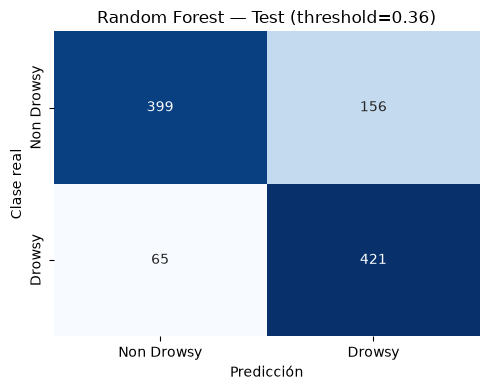

,subject_id,n_windows,model,threshold,Accuracy,Recall_Drowsy,Precision_Drowsy,F1_Drowsy,FNR,FPR,ROC_AUC
0,01,105,Random Forest,0.36,0.5714,0.5741,0.5849,0.5794,0.4259,0.4314,0.5839
1,04,141,Random Forest,0.36,1.0000,1.0000,1.0000,1.0000,0.0000,0.0000,1.0000
2,06,111,Random Forest,0.36,0.4775,0.8095,0.4048,0.5397,0.1905,0.7246,0.4634
3,07,105,Random Forest,0.36,0.6286,0.9630,0.5843,0.7273,0.0370,0.7255,0.5105
4,14,105,Random Forest,0.36,0.9619,0.9259,1.0000,0.9615,0.0741,0.0000,0.9815
5,18,123,Random Forest,0.36,0.8049,1.0000,0.7500,0.8571,0.0000,0.4706,0.9962
6,32,135,Random Forest,0.36,0.8148,0.6389,0.6571,0.6479,0.3611,0.1212,0.8098
7,49,75,Random Forest,0.36,0.9867,1.0000,0.9600,0.9796,0.0000,0.0196,1.0000
8,55,141,Random Forest,0.36,0.8227,0.8077,0.8630,0.8344,0.1923,0.1587,0.8594


,F1_Drowsy
min,0.5397
max,1.0000
mean,0.7919
std,0.1757


In [9]:
selected_evaluation = (
    "validation_threshold" if not np.isclose(selected_threshold, 0.5)
    else "threshold_0.5"
)
selected_test_predictions = test_predictions[
    (test_predictions.model == selected_model_name)
    & (test_predictions.evaluation == selected_evaluation)
].copy()
selected_test_row = test_metrics[
    (test_metrics.model == selected_model_name)
    & (test_metrics.evaluation == selected_evaluation)
].iloc[0]
_, _, selected_matrix = metrics_at_threshold(
    selected_test_predictions.true_label,
    selected_test_predictions.probability_drowsy,
    selected_threshold,
)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(selected_matrix, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
            xticklabels=["Non Drowsy", "Drowsy"],
            yticklabels=["Non Drowsy", "Drowsy"])
ax.set_title(f"{selected_model_name} — Test (threshold={selected_threshold:.2f})")
ax.set_xlabel("Predicción")
ax.set_ylabel("Clase real")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "39_uta_landmarks_ml_test_confusion_matrix.png",
            dpi=160, bbox_inches="tight")
plt.show()

subject_rows = []
for subject_id, group in selected_test_predictions.groupby("subject_id"):
    metrics, _, _ = metrics_at_threshold(
        group.true_label, group.probability_drowsy, selected_threshold
    )
    subject_rows.append({
        "subject_id": subject_id, "n_windows": len(group),
        "model": selected_model_name, "threshold": selected_threshold, **metrics,
    })
test_by_subject = pd.DataFrame(subject_rows).sort_values("subject_id")
test_by_subject.to_csv(
    METRICS_DIR / "uta_landmarks_ml_test_by_subject.csv", index=False
)
display(test_by_subject.round(4))
display(test_by_subject.F1_Drowsy.agg(["min", "max", "mean", "std"]).to_frame("F1_Drowsy").round(4))

## 10. Importancia de variables

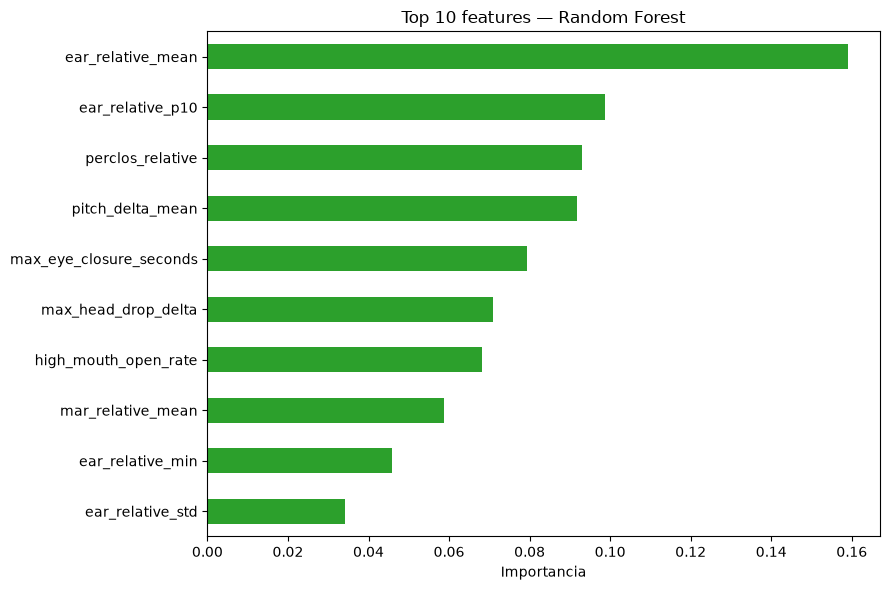

,importance
ear_relative_mean,0.159051
ear_relative_p10,0.098717
perclos_relative,0.093053
pitch_delta_mean,0.091811
max_eye_closure_seconds,0.079469
max_head_drop_delta,0.070840
high_mouth_open_rate,0.068099
mar_relative_mean,0.058771
ear_relative_min,0.045904
ear_relative_std,0.034127


In [10]:
feature_importance = pd.Series(
    selected_model.feature_importances_, index=feature_columns, name="importance"
).sort_values(ascending=False)
top_10_features = feature_importance.head(10)
fig, ax = plt.subplots(figsize=(9, 6))
top_10_features.sort_values().plot.barh(ax=ax, color="tab:green")
ax.set_title(f"Top 10 features — {selected_model_name}")
ax.set_xlabel("Importancia")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "40_uta_landmarks_ml_feature_importance.png",
            dpi=160, bbox_inches="tight")
plt.show()
display(top_10_features.to_frame())

## 11. Comparación con MobileNetV2 baseline

In [11]:
baseline = {
    "Accuracy": 0.5037, "Recall_Drowsy": 0.4889,
    "Precision_Drowsy": 0.5038, "F1_Drowsy": 0.4962,
    "FNR": 0.5111, "FPR": 0.4815, "ROC_AUC": 0.4435,
}
comparison_rows = [{"Model": "MobileNet baseline", **baseline}]
for model_name in ["Random Forest", "XGBoost"]:
    row = test_metrics[
        (test_metrics.model == model_name)
        & (test_metrics.evaluation == "threshold_0.5")
    ].iloc[0]
    comparison_rows.append({
        "Model": model_name,
        **{metric: float(row[metric]) for metric in baseline},
    })
comparison = pd.DataFrame(comparison_rows)
comparison.to_csv(METRICS_DIR / "uta_mobilenet_vs_landmarks_ml.csv", index=False)
display(comparison.round(4))

,Model,Accuracy,Recall_Drowsy,Precision_Drowsy,F1_Drowsy,FNR,FPR,ROC_AUC
0,MobileNet baseline,0.5037,0.4889,0.5038,0.4962,0.5111,0.4815,0.4435
1,Random Forest,0.7743,0.7016,0.7912,0.7437,0.2984,0.1622,0.8508
2,XGBoost,0.7589,0.6667,0.7845,0.7208,0.3333,0.1604,0.8335


## 12. Conclusión

In [12]:
subject_f1_summary = test_by_subject.F1_Drowsy.agg(["min", "max", "mean", "std"])
selected_metrics = {metric: float(selected_test_row[metric]) for metric in baseline}
deltas = {metric: selected_metrics[metric] - baseline[metric] for metric in baseline}
top_names = top_10_features.index.tolist()
eye_features = [name for name in top_names if "ear" in name or "perclos" in name or "closure" in name]
mouth_features = [name for name in top_names if "mar" in name or "mouth" in name]
pose_features = [name for name in top_names if any(key in name for key in ["pitch", "yaw", "roll", "head"])]

if (
    deltas["Recall_Drowsy"] > 0
    and deltas["F1_Drowsy"] >= 0.05
    and deltas["ROC_AUC"] >= 0.05
    and selected_metrics["FPR"] <= 0.45
    and subject_f1_summary["std"] <= 0.25
):
    recommendation = "A"
    recommendation_text = "ML clásico con landmarks se selecciona como modelo principal."
elif (
    deltas["Recall_Drowsy"] > 0
    and deltas["F1_Drowsy"] > 0
    and deltas["ROC_AUC"] > 0
):
    recommendation = "B"
    recommendation_text = "Mejora parcialmente pero requiere ajustes moderados."
else:
    recommendation = "C"
    recommendation_text = "No mejora suficientemente la generalización."

conclusions = [
    f"1. **Generalización frente a MobileNetV2:** cambios del modelo principal: Accuracy {deltas['Accuracy']:+.3f}, F1 {deltas['F1_Drowsy']:+.3f} y AUC {deltas['ROC_AUC']:+.3f}.",
    f"2. **Mejor modelo según Validation:** {selected_model_name}, threshold {selected_threshold:.2f}.",
    f"3. **Variables más importantes:** {', '.join(top_names)}. Ojos: {eye_features}; boca: {mouth_features}; pose: {pose_features}.",
    f"4. **Recall:** cambia {deltas['Recall_Drowsy']:+.3f} respecto a MobileNet.",
    f"5. **FNR/FPR:** {selected_metrics['FNR']:.3f}/{selected_metrics['FPR']:.3f}, cambios {deltas['FNR']:+.3f}/{deltas['FPR']:+.3f}.",
    f"6. **Variabilidad por sujeto:** F1 {subject_f1_summary['min']:.3f}–{subject_f1_summary['max']:.3f}, std {subject_f1_summary['std']:.3f}.",
    f"7. **Adecuación como modelo principal:** {recommendation_text}",
    f"\n### Recomendación {recommendation}\n\n{recommendation_text}",
]
display(Markdown("\n\n".join(conclusions)))

1. **Generalización frente a MobileNetV2:** cambios del modelo principal: Accuracy +0.284, F1 +0.296 y AUC +0.407.

2. **Mejor modelo según Validation:** Random Forest, threshold 0.36.

3. **Variables más importantes:** ear_relative_mean, ear_relative_p10, perclos_relative, pitch_delta_mean, max_eye_closure_seconds, max_head_drop_delta, high_mouth_open_rate, mar_relative_mean, ear_relative_min, ear_relative_std. Ojos: ['ear_relative_mean', 'ear_relative_p10', 'perclos_relative', 'max_eye_closure_seconds', 'ear_relative_min', 'ear_relative_std']; boca: ['high_mouth_open_rate', 'mar_relative_mean']; pose: ['pitch_delta_mean', 'max_head_drop_delta'].

4. **Recall:** cambia +0.377 respecto a MobileNet.

5. **FNR/FPR:** 0.134/0.281, cambios -0.377/-0.200.

6. **Variabilidad por sujeto:** F1 0.540–1.000, std 0.176.

7. **Adecuación como modelo principal:** ML clásico con landmarks se selecciona como modelo principal.


### Recomendación A

ML clásico con landmarks se selecciona como modelo principal.

## 13. Verificación final

In [13]:
total_seconds = time.perf_counter() - experiment_start
generated_files = [
    METRICS_DIR / "uta_landmarks_ml_test_metrics.csv",
    METRICS_DIR / "uta_landmarks_ml_test_predictions.csv",
    METRICS_DIR / "uta_landmarks_ml_test_by_subject.csv",
    METRICS_DIR / "uta_mobilenet_vs_landmarks_ml.csv",
    model_path,
    FIGURES_DIR / "39_uta_landmarks_ml_test_confusion_matrix.png",
    FIGURES_DIR / "40_uta_landmarks_ml_feature_importance.png",
]
assert all(path.exists() for path in generated_files)
assert train_subjects.isdisjoint(validation_subjects)
assert train_subjects.isdisjoint(test_subjects)
assert validation_subjects.isdisjoint(test_subjects)

print("Modelos entrenados: Random Forest, XGBoost")
print(f"Tiempo total: {total_seconds:.2f} s")
print("Métricas Validation threshold=0.5:")
display(validation_metrics.round(4))
print(f"Modelo seleccionado: {selected_model_name}")
print(f"Threshold seleccionado: {selected_threshold:.2f}")
print("Métricas Test del modelo principal:")
display(pd.DataFrame([selected_metrics]).round(4))
print(f"F1 por sujeto min/max/media/std: {subject_f1_summary['min']:.4f} / {subject_f1_summary['max']:.4f} / {subject_f1_summary['mean']:.4f} / {subject_f1_summary['std']:.4f}")
print("Top 10 features:", top_names)
print(f"Recomendación: {recommendation}")
print("Archivos generados:")
for path in generated_files:
    print("-", path.relative_to(PROJECT_ROOT).as_posix())

Modelos entrenados: Random Forest, XGBoost
Tiempo total: 2.23 s
Métricas Validation threshold=0.5:


,model,threshold,Accuracy,Recall_Drowsy,Precision_Drowsy,F1_Drowsy,FNR,FPR,ROC_AUC,Selection_Utility
0,Random Forest,0.5,0.7910,0.6899,0.8878,0.7764,0.3101,0.0968,0.8673,0.7833
1,XGBoost,0.5,0.7727,0.6880,0.8513,0.7610,0.3120,0.1333,0.8576,0.7706


Modelo seleccionado: Random Forest
Threshold seleccionado: 0.36
Métricas Test del modelo principal:


,Accuracy,Recall_Drowsy,Precision_Drowsy,F1_Drowsy,FNR,FPR,ROC_AUC
0,0.7877,0.8663,0.7296,0.7921,0.1337,0.2811,0.8508


F1 por sujeto min/max/media/std: 0.5397 / 1.0000 / 0.7919 / 0.1757
Top 10 features: ['ear_relative_mean', 'ear_relative_p10', 'perclos_relative', 'pitch_delta_mean', 'max_eye_closure_seconds', 'max_head_drop_delta', 'high_mouth_open_rate', 'mar_relative_mean', 'ear_relative_min', 'ear_relative_std']
Recomendación: A
Archivos generados:
- outputs/metrics/uta_landmarks_ml_test_metrics.csv
- outputs/metrics/uta_landmarks_ml_test_predictions.csv
- outputs/metrics/uta_landmarks_ml_test_by_subject.csv
- outputs/metrics/uta_mobilenet_vs_landmarks_ml.csv
- models/fatigueguard_landmarks_ml_best.pkl
- outputs/figures/39_uta_landmarks_ml_test_confusion_matrix.png
- outputs/figures/40_uta_landmarks_ml_feature_importance.png
